In [3]:
# Import the libraries you'll need
import pandas as pd   
import numpy as np  
import matplotlib.pyplot as plt    
import seaborn as sns  

# Make plots look nicer 
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [4]:
# Load the dataset
df = pd.read_csv('../Data/fake_job_postings.csv')

print("shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

shape: (17880, 18)
Columns: ['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [5]:
#Get infor about data types and missing values
df.info()

#Statistical summary of numeric columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


fraudulent
0    17014
1      866
Name: count, dtype: int64
fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64


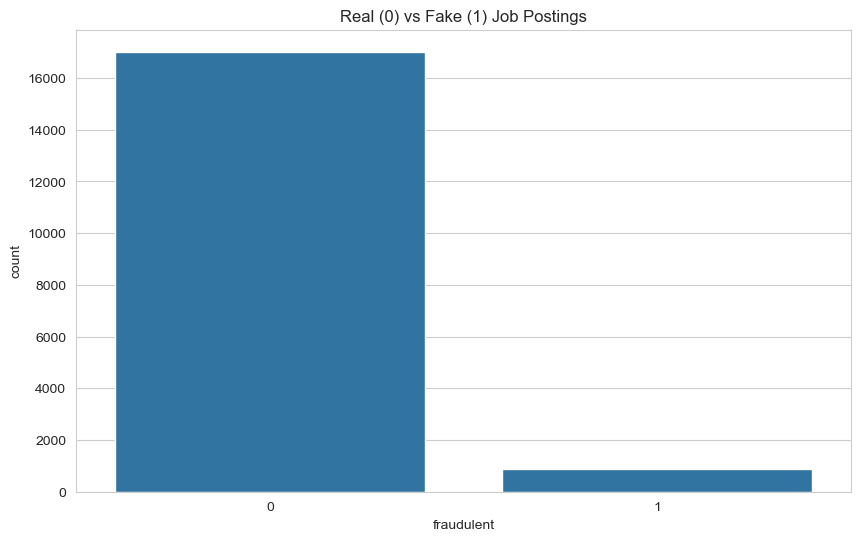

In [6]:
# count real vs fake
print(df['fraudulent'].value_counts())
print(df['fraudulent'].value_counts(normalize=True) * 100)

# visualize it
sns.countplot(x='fraudulent', data=df)
plt.title('Real (0) vs Fake (1) Job Postings')
plt.savefig('../Output/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Count and percentage of missing values per column
missing = df.isnull().sum()
missing_percentage = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_percentage})
print(missing_df.sort_values('Percent', ascending=False))

                     Missing    Percent
salary_range           15012  83.959732
department             11547  64.580537
required_education      8105  45.329978
benefits                7212  40.335570
required_experience     7050  39.429530
function                6455  36.101790
industry                4903  27.421700
employment_type         3471  19.412752
company_profile         3308  18.501119
requirements            2696  15.078300
location                 346   1.935123
description                1   0.005593
title                      0   0.000000
job_id                     0   0.000000
telecommuting              0   0.000000
has_questions              0   0.000000
has_company_logo           0   0.000000
fraudulent                 0   0.000000


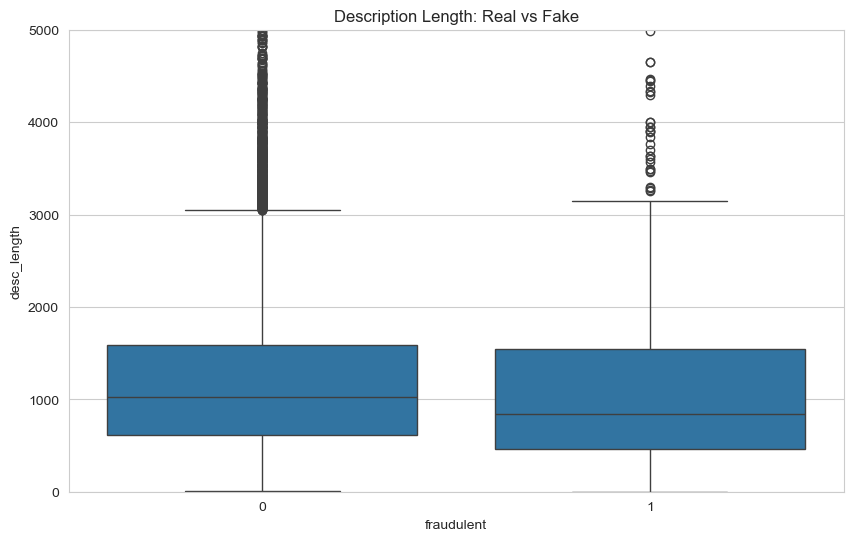

fraudulent
0    1221.219701
1    1154.834873
Name: desc_length, dtype: float64


In [8]:
# add a column for description length
df['desc_length'] = df['description'].fillna('').apply(len)

# compare description length for real vs fake
sns.boxplot(x='fraudulent', y='desc_length', data=df)
plt.title('Description Length: Real vs Fake')
plt.ylim(0, 5000)   # cut off outliers
plt.savefig('../Output/02_description_length.png', dpi=150, bbox_inches='tight')
plt.show()

# averages
print(df.groupby('fraudulent')['desc_length'].mean())

In [9]:
# Top countries for fake postings
df['country'] = df['location'].fillna('').apply(lambda x: x.split(',')[0])
fake_countries = df[df['fraudulent']==1]['country'].value_counts().head(10)
print("Top 10 countries with fake postings:")
print(fake_countries)

#Employment type breakdown
pd.crosstab(df['employment_type'], df['fraudulent'], normalize='index') * 100


Top 10 countries with fake postings:
country
US    730
AU     40
GB     23
       19
MY     12
CA     12
QA      6
BH      5
IN      4
PL      3
Name: count, dtype: int64


fraudulent,0,1
employment_type,,
Contract,97.112861,2.887139
Full-time,95.783133,4.216867
Other,93.392070,6.607930
Part-time,90.715182,9.284818
Temporary,99.170124,0.829876


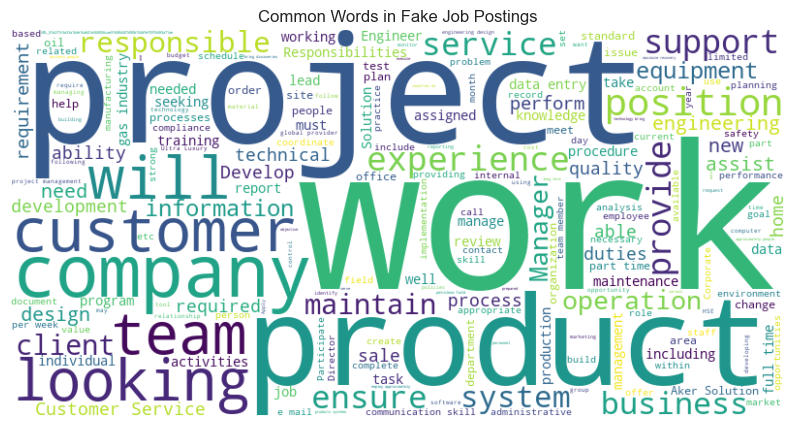

In [10]:
from wordcloud import WordCloud

# combine all fake descriptions into one big string
fake_text = ' '.join(df[df['fraudulent']==1]['description'].fillna('').astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(fake_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Common Words in Fake Job Postings')
plt.savefig('../Output/03_wordcloud_fake.png', dpi=150, bbox_inches='tight')
plt.show()

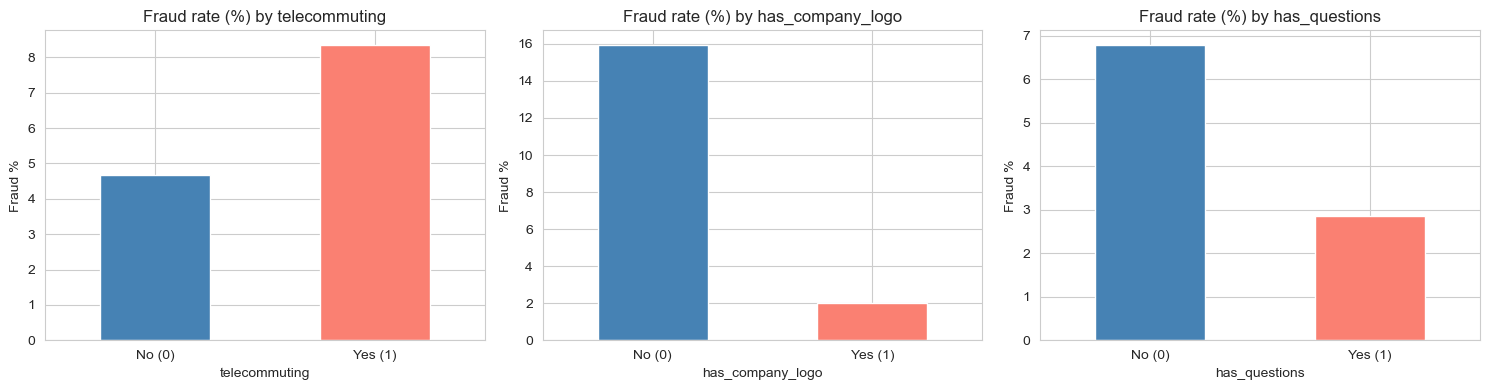

In [11]:
# check fraud rate for each binary column
binary_features = ['telecommuting', 'has_company_logo', 'has_questions']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(binary_features):
    rates = df.groupby(col)['fraudulent'].mean() * 100   # mean of 0/1 = fraud rate
    rates.plot(kind='bar', ax=axes[i], color=['steelblue', 'salmon'])
    axes[i].set_title(f'Fraud rate (%) by {col}')
    axes[i].set_ylabel('Fraud %')
    axes[i].set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)

plt.tight_layout()
plt.savefig('../Output/04_fraud_rate_binary.png', dpi=150, bbox_inches='tight')
plt.show()

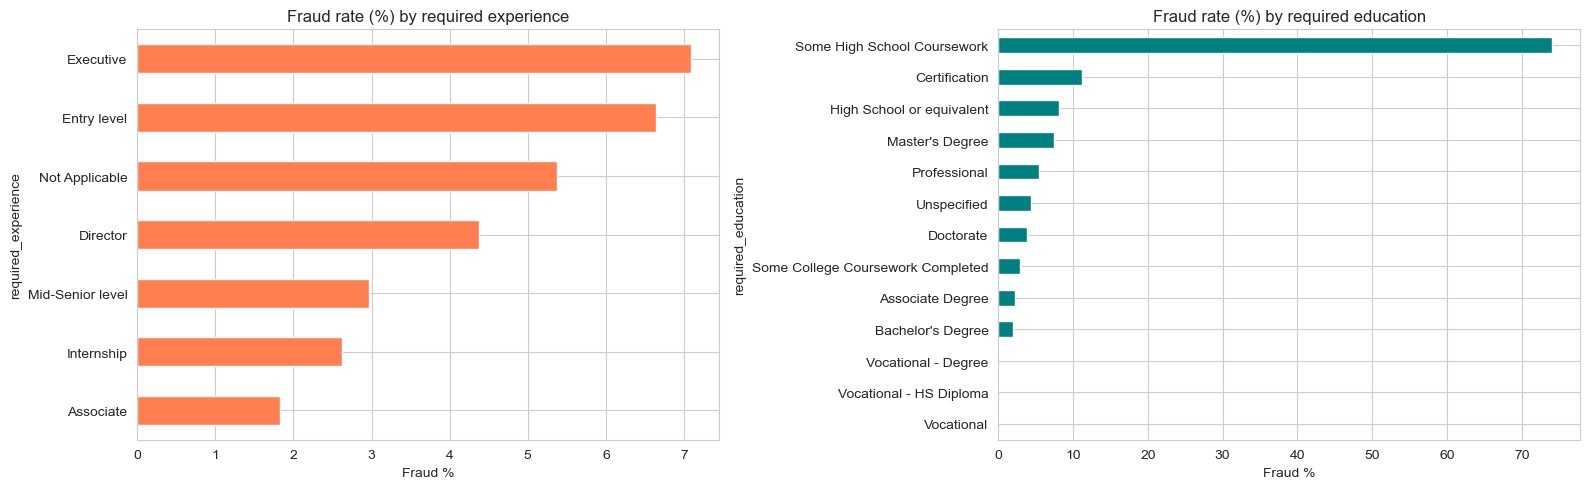

In [12]:
# fraud rate by required experience and education
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

exp_rate = df.groupby('required_experience')['fraudulent'].mean().sort_values() * 100
exp_rate.plot(kind='barh', ax=axes[0], color='coral')
axes[0].set_title('Fraud rate (%) by required experience')
axes[0].set_xlabel('Fraud %')

edu_rate = df.groupby('required_education')['fraudulent'].mean().sort_values() * 100
edu_rate.plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Fraud rate (%) by required education')
axes[1].set_xlabel('Fraud %')

plt.tight_layout()
plt.savefig('../Output/05_fraud_rate_exp_edu.png', dpi=150, bbox_inches='tight')
plt.show()

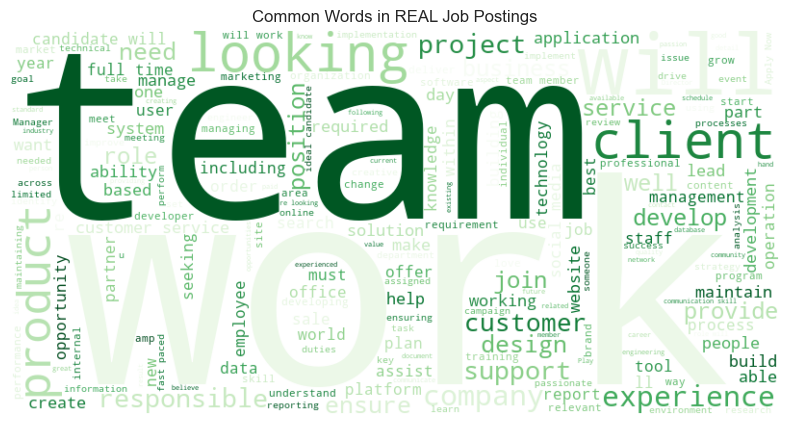

In [13]:
# same idea but for real postings (for comparison)
real_text = ' '.join(df[df['fraudulent']==0]['description'].fillna('').astype(str))

wordcloud_real = WordCloud(width=800, height=400, background_color='white',
                           colormap='Greens').generate(real_text)

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud_real, interpolation='bilinear')
plt.axis('off')
plt.title('Common Words in REAL Job Postings')
plt.savefig('../Output/06_wordcloud_real.png', dpi=150, bbox_inches='tight')
plt.show()

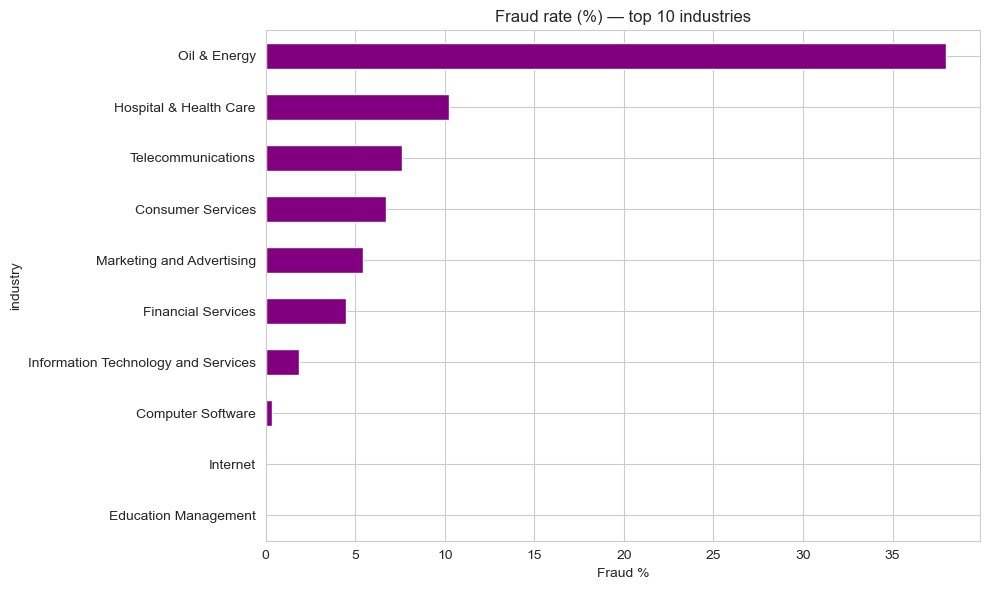

                                     count  fraud_pct
industry                                             
Education Management                   822       0.00
Internet                              1062       0.00
Computer Software                     1376       0.36
Information Technology and Services   1734       1.85
Financial Services                     779       4.49
Marketing and Advertising              828       5.43
Consumer Services                      358       6.70
Telecommunications                     342       7.60
Hospital & Health Care                 497      10.26
Oil & Energy                           287      37.98


In [14]:
# fraud rate across top 10 industries
top_industries = df['industry'].value_counts().head(10).index
ind_data = df[df['industry'].isin(top_industries)]

ind_fraud = ind_data.groupby('industry')['fraudulent'].agg(['mean', 'count'])
ind_fraud['fraud_pct'] = ind_fraud['mean'] * 100
ind_fraud = ind_fraud.sort_values('fraud_pct', ascending=True)

ind_fraud['fraud_pct'].plot(kind='barh', figsize=(10, 6), color='purple')
plt.title('Fraud rate (%) — top 10 industries')
plt.xlabel('Fraud %')
plt.tight_layout()
plt.savefig('../Output/07_fraud_by_industry.png', dpi=150, bbox_inches='tight')
plt.show()

print(ind_fraud[['count', 'fraud_pct']].round(2))

## EDA Summary

Key things from the data:

- Heavy class imbalance — only ~4.84% fake (866 out of 17,880). Need to use F1/recall, not accuracy.
- `has_company_logo` looks like the strongest signal. Postings without a logo are way more likely to be fake.
- Missing fields (`company_profile`, `requirements`, `benefits`) are more common in fake postings — so missingness itself is useful.
- Part-time and "Other" employment types have higher fraud rates than full-time or contract.
- Fake postings use words like *work from home*, *earn*, *data entry*. Real ones use *team*, *skill*, *experience*.
- US has the most fake postings in absolute numbers but the rate is higher in some smaller countries.

### Next steps for modelling
- Stratified train/test split
- Try `class_weight='balanced'` and SMOTE, compare them
- Use TF-IDF on the text + the binary features
- Drop `salary_range` (84% missing)
- Focus on F1 on the fake class and AUC-ROC

In [15]:
# Additional imports for preprocessing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

In [16]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Clean and lemmatise raw job posting text.
    Motivated by EDA finding: fake posts have distinct vocabulary
    that is revealed after removing noise.
    """
    if pd.isna(text):
        return ''
    
    # Step 1: Lowercase
    text = text.lower()
    
    # Step 2: Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    
    # Step 3: Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Step 4: Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Step 5: Tokenise, remove stopwords, lemmatise
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(w)
        for w in tokens
        if w not in stop_words and len(w) > 2
    ]
    
    return ' '.join(tokens)


# Demonstrate on a fake-sounding example
example_fake = "URGENT!! Work from home & earn $500 daily. No experience needed! Send personal details NOW."
example_real = "We are looking for an experienced Software Engineer to join our growing team in London."

print('--- FAKE example ---')
print('Before:', example_fake)
print('After: ', clean_text(example_fake))

print('\n--- REAL example ---')
print('Before:', example_real)
print('After: ', clean_text(example_real))

--- FAKE example ---
Before: URGENT!! Work from home & earn $500 daily. No experience needed! Send personal details NOW.
After:  urgent work home earn daily experience needed send personal detail

--- REAL example ---
Before: We are looking for an experienced Software Engineer to join our growing team in London.
After:  looking experienced software engineer join growing team london


In [19]:
# Combine key text columns
text_columns = ['title', 'company_profile', 'description', 'requirements', 'benefits']

df['combined_text'] = df[text_columns].fillna('').apply(
    lambda row: ' '.join(row.values.astype(str)), axis=1
)

# Apply cleaning to combined text

df['cleaned_text'] = df['combined_text'].apply(clean_text)


# Quick check
print('\nSample cleaned text (first row):')
print(df['cleaned_text'].iloc[0][:300], '...')
print('\nAverage cleaned text length:', round(df['cleaned_text'].str.split().str.len().mean()), 'words')


Sample cleaned text (first row):
marketing intern food created groundbreaking award winning cooking site support connect celebrate home cook give everything need one place top editorial business engineering team focused using technology find new better way connect people around specific food interest offer superb highly curated inf ...

Average cleaned text length: 243 words


In [20]:
# Create binary missingness flags
df['has_company_profile'] = df['company_profile'].notna().astype(int)
df['has_requirements']    = df['requirements'].notna().astype(int)
df['has_benefits']        = df['benefits'].notna().astype(int)

# Verify the flags are predictive — fraud rate should be higher when flag = 0
print('Fraud rate (%) by has_company_profile:')
print((df.groupby('has_company_profile')['fraudulent'].mean() * 100).round(2))
print('  -> Postings with NO company profile have higher fraud rate\n')

print('Fraud rate (%) by has_requirements:')
print((df.groupby('has_requirements')['fraudulent'].mean() * 100).round(2))
print('  -> Postings with NO requirements listed have higher fraud rate\n')

print('Fraud rate (%) by has_benefits:')
print((df.groupby('has_benefits')['fraudulent'].mean() * 100).round(2))
print('  -> Postings with NO benefits listed have higher fraud rate')

Fraud rate (%) by has_company_profile:
has_company_profile
0    17.74
1     1.91
Name: fraudulent, dtype: float64
  -> Postings with NO company profile have higher fraud rate

Fraud rate (%) by has_requirements:
has_requirements
0    5.71
1    4.69
Name: fraudulent, dtype: float64
  -> Postings with NO requirements listed have higher fraud rate

Fraud rate (%) by has_benefits:
has_benefits
0    5.05
1    4.71
Name: fraudulent, dtype: float64
  -> Postings with NO benefits listed have higher fraud rate


In [ ]:
metadata_cols = [
    'telecommuting',          # from original dataset
    'has_company_logo',       # from original dataset 
    'has_questions',          # from original dataset
    'has_company_profile',    # NEW — created from missingness
    'has_requirements',       # NEW — created from missingness
    'has_benefits'            # NEW — created from missingness
]

print('Features going into the model:')
print('\n[TEXT FEATURES]')
print('  cleaned_text → TF-IDF vectorisation (up to 5,000 features)')
print('  Source: title + company_profile + description + requirements + benefits')
print('\n[METADATA FEATURES]')
for col in metadata_cols:
    tag = '(NEW from EDA)' if col in ['has_company_profile', 'has_requirements', 'has_benefits'] else '(original dataset)'
    print(f'  {col} {tag}')
print('\n[TARGET]')
print('  fraudulent — 0 = real, 1 = fake')
print('\n[DROPPED]')
print('  salary_range — 84% missing, not usable')
print('  location, country, job_id, department — not relevant to text-based detection')

Features going into the model:

[TEXT FEATURES]
  cleaned_text → TF-IDF vectorisation (up to 5,000 features)
  Source: title + company_profile + description + requirements + benefits

[METADATA FEATURES]
  telecommuting (original dataset)
  has_company_logo (original dataset)
  has_questions (original dataset)
  has_company_profile (NEW from EDA)
  has_requirements (NEW from EDA)
  has_benefits (NEW from EDA)

[TARGET]
  fraudulent — 0 = real, 1 = fake

[DROPPED]
  salary_range — 84% missing, not usable
  location, country, job_id, department — not relevant to text-based detection


In [22]:
# Select only columns needed for modelling
cols_to_save = [
    'cleaned_text',
    'telecommuting',
    'has_company_logo',
    'has_questions',
    'has_company_profile',
    'has_requirements',
    'has_benefits',
    'fraudulent'           # target variable
]

df_clean = df[cols_to_save].copy()

# Save to Data folder
df_clean.to_csv('../Data/cleaned_data.csv', index=False)

print('Cleaned dataset saved to: ../Data/cleaned_data.csv')
print('Shape:', df_clean.shape)
print('\nColumns saved:', df_clean.columns.tolist())
print('\nClass distribution:')
print(df_clean['fraudulent'].value_counts())
print('Fraud %:', round(df_clean['fraudulent'].mean() * 100, 2))
print('\nNotebook 02 will load this file. Raw data is unchanged.')

Cleaned dataset saved to: ../Data/cleaned_data.csv
Shape: (17880, 8)

Columns saved: ['cleaned_text', 'telecommuting', 'has_company_logo', 'has_questions', 'has_company_profile', 'has_requirements', 'has_benefits', 'fraudulent']

Class distribution:
fraudulent
0    17014
1      866
Name: count, dtype: int64
Fraud %: 4.84

Notebook 02 will load this file. Raw data is unchanged.
